# 📚 Tutorial: Pareto Front Analysis

Welcome to this notebook! Its purpose is to analyze and visualize **Pareto Fronts**, a fundamental tool in multi-objective optimization.

A **Pareto Front** represents a set of solutions where it's impossible to improve one objective without worsening another. They are the "best possible" solutions in terms of trade-offs.

**For more experienced users, this notebook is ready to use. The tutorial is designed to help those less familiar with Python get comfortable with the data and how we use it in this analysis.**

---
### 👣 Key Steps in This Tutorial

This notebook is divided into sections that will guide you through the entire analysis process.

#### Step 1: Create the Example Data Files (Run Only Once)

The first thing to do is create the data files we will use.
* Go to the section **"📝 Tutorial: Create Fictitious Data Files"**.
* Run the code cell. This will create a folder named `tutorial_data/` and populate it with three CSV files.

Once you have run this cell, you will not need it again.

#### Step 2: Load and Analyze the Data

Now that you have the data, you can proceed with the main sections:

1.  **2D Analysis**:
    * We will load the `tutorial_data_2d.csv` and `true_pareto_front_2d.csv` files.
    * The `calculate_pareto_front` function will identify the optimal solutions in our dataset.
    * We will then calculate a series of **performance metrics** (like Hypervolume, GD, RMSD, etc.) to evaluate the quality of our found front by comparing it to the "true" reference front.

2.  **3D Analysis & Advanced Visualization**:
    * We will repeat a similar process using the `tutorial_data_3d.csv` file.
    * We will explore the **Parallel Coordinates Plot**, a powerful technique for visualizing data with more than two dimensions (like our 3D data) in a 2D format. This allows us to identify trends and trade-offs between the various objectives.

#### Important Concepts

* **Minimization vs. Maximization**: Remember that our front calculation function is designed for minimization. The notebook contains a markdown section that explains how to easily adapt it for maximization objectives.
* **True Pareto Front**: We need an ideal reference front to calculate many of the metrics. The dedicated section explains why this is a key concept for validation.

Enjoy the analysis!


## Setup and Library Imports

In this section, we install and import the necessary libraries for the analysis. The main libraries we will use are:
- **pandas**: for data manipulation and analysis.
- **numpy**: for numerical computation.
- **matplotlib**: for data visualization.



In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

## 📝 Tutorial: Creating the Fictitious Data Files (Run Only Once)

This section contains the necessary code to create the fictitious CSV files used in this notebook. Run this cell **only once** to generate the following files in your folder:

* `tutorial_data_2d.csv`: A dataset with many points for 2D analysis.
* `tutorial_data_3d.csv`: A dataset with many points for 3D analysis.
* `true_pareto_front_2d.csv`: An "ideal" Pareto front for comparing 2D metrics.

Once the files are created, you can comment out or delete this cell.

---

In [35]:
# Define the name of the tutorial folder
folder_name = 'tutorial_data'

# Create the folder if it does not exist
os.makedirs(folder_name, exist_ok=True)
print(f"Directory '{folder_name}' created or already exists.")

# --- 1. Create the 2D data CSV file ---
print("Creating 'tutorial_data_2d.csv'...")
np.random.seed(42)
data_2d = pd.DataFrame({
    'Obj1': np.random.rand(500) * 1.5,
    'Obj2': np.random.rand(500) * 1.5
})
data_2d.loc[250:, :] += 0.5
path_2d = os.path.join(folder_name, 'tutorial_data_2d.csv')
data_2d.to_csv(path_2d, index=False)
print(f"-> File saved to: {path_2d}")

# --- 2. Create the 3D data CSV file ---
print("\nCreating 'tutorial_data_3d.csv'...")
np.random.seed(0)
data_3d = pd.DataFrame({
    'Obj1': np.random.rand(800),
    'Obj2': np.random.rand(800),
    'Obj3': np.random.rand(800)
})
data_3d.loc[400:, :] += 0.6
path_3d = os.path.join(folder_name, 'tutorial_data_3d.csv')
data_3d.to_csv(path_3d, index=False)
print(f"-> File saved to: {path_3d}")

# --- 3. Create the 2D True Pareto Front file ---
print("\nCreating 'true_pareto_front_2d.csv'...")
np.random.seed(1)
x_values = np.linspace(0, 1, 200)
y_values = 1 - np.sqrt(x_values) + np.random.normal(0, 0.01, 200)
true_front = pd.DataFrame({
    'Obj1': x_values,
    'Obj2': np.clip(y_values, 0, 1)
})
true_front = true_front.sort_values(by='Obj1')
path_true_front = os.path.join(folder_name, 'true_pareto_front_2d.csv')
true_front.to_csv(path_true_front, index=False)
print(f"-> File saved to: {path_true_front}")

# --- 4. Creazione del file del "True Pareto Front" 3D ---
print("\nCreazione di 'true_pareto_front_3d.csv'...")
np.random.seed(2)
phi, theta = np.meshgrid(np.linspace(0, np.pi/2, 40), np.linspace(0, np.pi/2, 40))
x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)
true_front_3d = pd.DataFrame({
    'Obj1': x.ravel(),
    'Obj2': y.ravel(),
    'Obj3': z.ravel()
})
path_true_front_3d = os.path.join(folder_name, 'true_pareto_front_3d.csv')
true_front_3d.to_csv(path_true_front_3d, index=False)
print(f"-> File salvato in: {path_true_front_3d}")

print("\n✅ All tutorial files have been generated in the 'tutorial_data' folder.")

Directory 'tutorial_data' created or already exists.
Creating 'tutorial_data_2d.csv'...
-> File saved to: tutorial_data/tutorial_data_2d.csv

Creating 'tutorial_data_3d.csv'...
-> File saved to: tutorial_data/tutorial_data_3d.csv

Creating 'true_pareto_front_2d.csv'...
-> File saved to: tutorial_data/true_pareto_front_2d.csv

Creazione di 'true_pareto_front_3d.csv'...
-> File salvato in: tutorial_data/true_pareto_front_3d.csv

✅ All tutorial files have been generated in the 'tutorial_data' folder.


In [36]:
try:
    # Specify the correct path, including the folder name
    path_2d = 'tutorial_data/tutorial_data_2d.csv'
    path_3d = 'tutorial_data/tutorial_data_3d.csv'
    path_true_front = 'tutorial_data/true_pareto_front_2d.csv'
    path_true_front_3d = 'tutorial_data/true_pareto_front_3d.csv'

    # Load the data
    tutorial_data_2d = pd.read_csv(path_2d)
    tutorial_data_3d = pd.read_csv(path_3d)
    true_front_2d = pd.read_csv(path_true_front)
    true_front_3d = pd.read_csv(path_true_front_3d)

    print("✅ All files from the 'tutorial_data' folder have been loaded successfully.")

except FileNotFoundError as e:
    print(f"❌ ERROR: File not found.")
    print("Please ensure you have run the previous cell to create the files and the folder.")

✅ All files from the 'tutorial_data' folder have been loaded successfully.


## Template for File Import/Export

This section provides a template for loading your data from CSV files and saving it. Modify the file paths according to your needs.

In [37]:
#YOUR_DATA_df = pd.read_csv('path/to/your/file.csv')

# Example of how to read multiple CSV files and combine them

# file_paths = ['path/to/file1.csv', 'path/to/file2.csv', 'path/to/file3.csv']
# dataframes = [pd.read_csv(fp) for fp in file_paths]
# combined_df = pd.concat(dataframes, ignore_index=True)

# Example of how to save a DataFrame to a CSV file
# combined_df.to_csv('path/to/output/combined_file.csv', index=False)

## Core Function to Calculate the Pareto Front

This is the function for identifying non-dominated solutions. **It is assumed that all objectives should be minimized.**

### How to Handle Maximization Objectives 🎯

The `calculate_pareto_front` function is designed for **minimization** problems, where lower values are considered better. However, you can easily use it for **maximization** objectives with a simple trick: **inverting the sign**.

For every column (objective) you wish to maximize, you simply need to **multiply all of its values by -1** before passing the data to the function. Maximizing a value `X` (e.g., 100) is mathematically equivalent to minimizing its opposite, `-X` (e.g., -100).

---

#### Practical Example:

Let's assume we want to:
* **Maximize** `FXR`
* **Maximize** `GPBAR1`
* **Minimize** `SA score`

Here is how you would prepare the data:

```python
# 1. Your original data
original_data = pd.DataFrame({
    'Obj1': [10, 20, 30],      # To be maximized
    'Obj2': [50, 40, 60],   # To be maximized
    'Obj3': [0.5, 0.8, 0.2] # To be minimized
})

# 2. Create a copy for the transformation
data_for_pareto = original_data.copy()

# 3. Invert the sign of the columns to be maximized
data_for_pareto['Obj1'] *= -1
data_for_pareto['Obj2'] *= -1
# 'SA score' remains unchanged because it's already a minimization objective

# Now 'data_for_pareto' is ready to be used with the function:
# pareto_points, _ = calculate_pareto_front(data_for_pareto.values)

# => Remember: when analyzing the results, you will need to multiply
#    the transformed columns by -1 again to revert them to their original values!

In [38]:
def calculate_pareto_front(data):
    """
    Calculates the Pareto front from a dataset.
    This is a corrected and robust implementation.
    A point is on the front if it is not dominated by any other point.
    Assumes minimization for all objectives.
    """
    num_points = data.shape[0]
    is_on_front = np.ones(num_points, dtype=bool)

    for i in range(num_points):
        for j in range(num_points):
            if i == j:
                continue

            # Check if point j dominates point i
            # j dominates i if it is better or equal on all objectives and strictly better on at least one
            if np.all(data[j] <= data[i]) and np.any(data[j] < data[i]):
                is_on_front[i] = False
                break # Point i is dominated, no need to check further

    return data[is_on_front], np.where(is_on_front)[0]

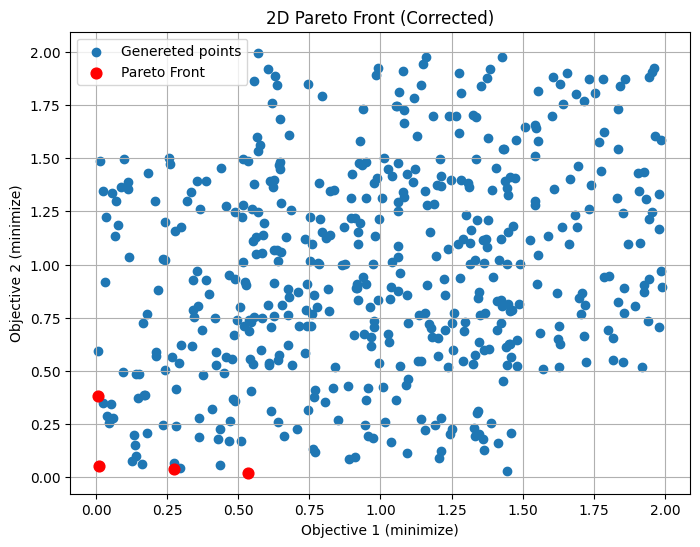

In [39]:
pareto_points_2d, pareto_indices_2d = calculate_pareto_front(tutorial_data_2d.values)

# Plot the 2D Pareto front
plt.figure(figsize=(8, 6))
plt.scatter(tutorial_data_2d['Obj1'], tutorial_data_2d['Obj2'], label='Genereted points')
plt.scatter(pareto_points_2d[:, 0], pareto_points_2d[:, 1], color='red', s=60, zorder=3, label='Pareto Front')
plt.title('2D Pareto Front')
plt.xlabel('Objective 1 (minimize)')
plt.ylabel('Objective 2 (minimize)')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
pareto_points_3d, pareto_indices_3d = calculate_pareto_front(tutorial_data_3d.values)

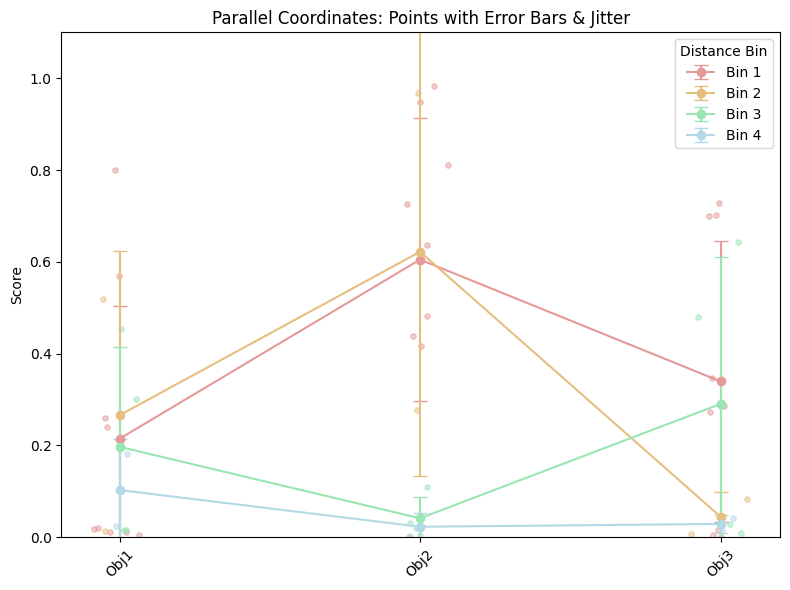

In [41]:
def plot_parallel_coordinates_points_jitter(
    pareto_front, columns, ideal_solution, class_column='Total Score', n_bins=4):
    """
    This is the function you provided to create a Parallel Coordinates Plot,
    grouping the data based on the distance from an ideal solution.
    """
    df_pareto = pd.DataFrame(pareto_front, columns=columns)

    # Calculate the distance from the ideal solution
    df_pareto[class_column] = df_pareto.apply(
        lambda row: np.linalg.norm(row[columns] - ideal_solution), axis=1
    )

    # Divide the data into 'bins' (groups)
    bins = np.linspace(
        df_pareto[class_column].min(),
        df_pareto[class_column].max(),
        n_bins + 1)
    df_pareto['distance_bin'] = pd.cut(
        df_pareto[class_column], bins=bins, labels=range(n_bins), include_lowest=True
    )

    # Custom colors
    custom_colors = [
        (0.9, 0.6, 0.6), (0.9, 0.75, 0.5), (0.6, 0.9, 0.7), (0.7, 0.85, 0.9)
    ]

    x_coords = np.arange(len(columns))
    plt.figure(figsize=(8, 6))

    for bin_idx in range(n_bins):
        bin_data = df_pareto[df_pareto['distance_bin'] == bin_idx]
        if bin_data.empty:
            continue
        color = custom_colors[bin_idx % len(custom_colors)]

        # Jittered points for each column
        for i, col in enumerate(columns):
            y = bin_data[col]
            x = np.random.normal(loc=x_coords[i], scale=0.04, size=len(y))
            plt.scatter(x, y, color=color, alpha=0.5, s=15, label=None)

        # Mean and standard deviation lines
        means = bin_data[columns].mean()
        stds = bin_data[columns].std()
        plt.errorbar(x_coords, means, yerr=stds, fmt='o-', color=color, capsize=5, label=f'Bin {bin_idx+1}')

    plt.xticks(x_coords, columns, rotation=45)
    plt.ylim(0, 1.1)
    plt.title('Parallel Coordinates: Points with Error Bars & Jitter')
    plt.ylabel('Score')
    plt.legend(title='Distance Bin')
    plt.tight_layout()
    plt.show()

# Define the column names and the ideal solution, as in your example
columns = ['Obj1', 'Obj2', 'Obj3']
ideal_solution = np.array([1.0, 1.0, 1.0])

# Call your function to create the plot pareto_points_2d
plot_parallel_coordinates_points_jitter(pareto_points_3d, columns, ideal_solution)

### The Concept of the "True Pareto Front" (Reference Front)

Before calculating performance metrics, it is crucial to understand the concept of a **"True Pareto Front,"** or reference front.

In real-world multi-objective optimization problems, the actual, optimal Pareto front is almost always unknown. If we knew it, we would have already solved the problem!

However, to **evaluate and compare the performance** of different algorithms or solutions (like our `Set A`), we need a "gold standard" or an ideal benchmark. For this purpose, we create a synthetic front based on a known mathematical function, which serves as our **"True Pareto Front"**.

#### Why is it necessary?

Metrics like **Generational Distance (GD)**, **RMSD**, and the **C-Metric** are comparative. They measure aspects such as:
* **Convergence**: How *close* is our found front (`Pareto A`) to the ideal front (`True Front`)? (GD, RMSD)
* **Coverage**: How many of the ideal solutions are dominated by the ones we found? (C-Metric)

Without a reference front, these metrics cannot be calculated.

In our notebook, we load this reference front from external files (`true_front_2d.csv` and `true_front_3d.csv`), which represent an ideal 2D curve and 3D surface for our fictitious problem.

In [42]:
# --- 2D Metric Functions ---
def get_number_of_points(front): return len(front)
def calculate_hypervolume_2d(front, ref_point):
    front_sorted = front[front[:, 0].argsort()]
    hv = 0.0
    for i in range(len(front_sorted)):
        width = ref_point[0] - front_sorted[i,0] if i == 0 else front_sorted[i-1,0] - front_sorted[i,0]
        height = ref_point[1] - front_sorted[i,1]
        hv += width * height
    return hv
def calculate_auc_2d(front):
    if len(front) < 2: return 0
    front_sorted = front[front[:, 0].argsort()]
    return np.trapezoid(front_sorted[:,1], front_sorted[:,0])
def get_distances_to_true_front(front, true_front):
    if len(front) == 0: return []
    return [np.min(distance.cdist([p], true_front, 'euclidean')) for p in front]
def calculate_generational_distance(distances):
    if not distances: return float('inf')
    return np.mean(distances)
def calculate_rmsd(distances):
    if not distances: return float('inf')
    return np.sqrt(np.mean(np.square(distances)))
def calculate_c_metric(front_a, front_b):
    if len(front_a) == 0 or len(front_b) == 0: return 0
    dominated_count = 0
    for point_b in front_b:
        for point_a in front_a:
            if np.all(point_a <= point_b) and np.any(point_a < point_b):
                dominated_count += 1
                break # Point b is dominated by point a, no need to check further for this point_b
    return dominated_count / len(front_b)
def find_knee_point_2d(front):
    if len(front) < 3: return None
    normalized_front = (front - front.min(axis=0)) / (front.max(axis=0) - front.min(axis=0))
    distances_to_line = [np.linalg.norm(np.cross(normalized_front[-1]-normalized_front[0], normalized_front[0]-p)) for p in normalized_front]
    knee_index = np.argmax(distances_to_line)
    return front[knee_index]

# --- Execute 2D Metrics ---
print("--- DISTINCT METRICS FOR PARETO FRONT A (2D) ---")
ref_point_2d = np.array([0.1, 0.1])
distances_2d = get_distances_to_true_front(pareto_points_2d, true_front_2d[['Obj1', 'Obj2']].values)

print(f"1. Number of Points: {get_number_of_points(pareto_points_2d)}")
print(f"2. Hypervolume (HV): {calculate_hypervolume_2d(pareto_points_2d, ref_point_2d):.4f}")
print(f"3. Area Under Curve (AUC): {calculate_auc_2d(pareto_points_2d):.4f}")
print(f"4. Generational Distance (GD): {calculate_generational_distance(distances_2d):.4f}")
print(f"5. Root Mean Square Deviation (RMSD): {calculate_rmsd(distances_2d):.4f}")
print(f"6. C-Metric (C(A, B)): {calculate_c_metric(pareto_points_2d, true_front_2d[['Obj1', 'Obj2']].values):.4f}")
knee_2d = find_knee_point_2d(pareto_points_2d)
if knee_2d is not None: print(f"7. Knee Point: [{knee_2d[0]:.4f}, {knee_2d[1]:.4f}]")

--- DISTINCT METRICS FOR PARETO FRONT A (2D) ---
1. Number of Points: 4
2. Hypervolume (HV): -0.0625
3. Area Under Curve (AUC): 0.0211
4. Generational Distance (GD): 0.3135
5. Root Mean Square Deviation (RMSD): 0.3317
6. C-Metric (C(A, B)): 0.9600
7. Knee Point: [0.0104, 0.0550]


/tmp/ipython-input-4267175713.py:36: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances_to_line = [np.linalg.norm(np.cross(normalized_front[-1]-normalized_front[0], normalized_front[0]-p)) for p in normalized_front]


In [44]:
# --- 3D Metric Functions ---
def calculate_hypervolume_3d(front, ref_point, n_samples=10000):
    if len(front) == 0: return 0
    min_bounds = np.min(front, axis=0)
    samples = np.random.rand(n_samples, 3) * (ref_point - min_bounds) + min_bounds
    dominated_count = sum(1 for s in samples if any(np.all(p <= s) for p in front))
    return (dominated_count / n_samples) * np.prod(ref_point - min_bounds)
def find_knee_point_3d(front):
    if len(front) < 4: return None
    normalized_front = (front - front.min(axis=0)) / (front.max(axis=0) - front.min(axis=0))
    p1, p2, p3 = normalized_front[np.argmin(normalized_front[:, 0])], normalized_front[np.argmin(normalized_front[:, 1])], normalized_front[np.argmin(normalized_front[:, 2])]
    normal_vector = np.cross(p2 - p1, p3 - p1)
    distances_to_plane = [np.abs(np.dot(p - p1, normal_vector)) / np.linalg.norm(normal_vector) for p in normalized_front]
    knee_index = np.argmax(distances_to_plane)
    return front[np.argmax(distances_to_plane)]

# --- Execute 3D Metrics ---
print("\n--- DISTINCT METRICS FOR PARETO FRONT A (3D) ---")
ref_point_3d = np.array([2.0, 2.0, 2.0])
distances_3d = get_distances_to_true_front(pareto_points_3d, true_front_3d.values)

print(f"1. Number of Points: {get_number_of_points(pareto_points_3d)}")
print(f"2. Hypervolume (HV): {calculate_hypervolume_3d(pareto_points_3d, ref_point_3d):.4f} (estimated)")
print("3. AUC: Not applicable in 3D.")
print(f"4. Generational Distance (GD): {calculate_generational_distance(distances_3d):.4f}")
print(f"5. Root Mean Square Deviation (RMSD): {calculate_rmsd(distances_3d):.4f}")
print(f"6. C-Metric (C(A, B)): {calculate_c_metric(pareto_points_3d, true_front_3d.values):.4f}")
knee_3d = find_knee_point_3d(pareto_points_3d)
if knee_3d is not None: print(f"7. Knee Point: [{knee_3d[0]:.4f}, {knee_3d[1]:.4f}, {knee_3d[2]:.4f}]")


--- DISTINCT METRICS FOR PARETO FRONT A (3D) ---
1. Number of Points: 17
2. Hypervolume (HV): 7.9321 (estimated)
3. AUC: Not applicable in 3D.
4. Generational Distance (GD): 0.3216
5. Root Mean Square Deviation (RMSD): 0.4249
6. C-Metric (C(A, B)): 0.8825
7. Knee Point: [0.0247, 0.0440, 0.0157]
